<a href="https://colab.research.google.com/github/wezc0m/CIC-IDS-2018-Random-Forest/blob/main/CIC_IDS_2018_RF_with_SMOTE_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Library

In [1]:
# NumPy
# Digunakan untuk operasi numerik dan pengolahan array
import numpy as np

# Pandas
# Digunakan untuk membaca, mengolah, dan menganalisis dataset
import pandas as pd

# Matplotlib
# Digunakan untuk membuat visualisasi data
import matplotlib.pyplot as plt

# Seaborn
# Digunakan untuk membuat visualisasi statistik
import seaborn as sns

# Scikit-learn
# Digunakan untuk membagi dataset menjadi data training dan testing
from sklearn.model_selection import train_test_split, GridSearchCV

# Scikit-learn
# Digunakan untuk mengevaluasi performa model klasifikasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Scikit-learn (Random Forest)
# Digunakan untuk membuat dan melatih model Machine Learning untuk klasifikasi traffic jaringan
from sklearn.ensemble import RandomForestClassifier

# Imbalanced-learn
# Digunakan untuk menangani ketidakseimbangan jumlah kelas pada dataset menggunakan metode SMOTE
from imblearn.over_sampling import SMOTE

# 2. Load Dataset

In [2]:
# Membaca dataset CIC-IDS2018 dari file CSV
df = pd.read_csv("/content/cic.csv")

# Menampilkan 5 baris pertama dataset
print(df.head())

# Menampilkan ukuran dataset
# Hasil: (jumlah baris, 80 kolom)
print("Ukuran dataset:", df.shape)

# Menampilkan jumlah kolom
print("Jumlah kolom:", len(df.columns))

# Menampilkan nama seluruh kolom
print("\nNama kolom:")
print(df.columns.tolist())

   Dst Port  Protocol            Timestamp  Flow Duration  Tot Fwd Pkts  \
0         0         0  14/02/2018 08:31:01      112641719             3   
1         0         0  14/02/2018 08:33:50      112641466             3   
2         0         0  14/02/2018 08:36:39      112638623             3   
3        22         6  14/02/2018 08:40:13        6453966            15   
4        22         6  14/02/2018 08:40:23        8804066            14   

   Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
0             0                0                0                0   
1             0                0                0                0   
2             0                0                0                0   
3            10             1239             2273              744   
4            11             1143             2209              744   

   Fwd Pkt Len Min  ...  Fwd Seg Size Min  Active Mean  Active Std  \
0                0  ...                 0          0.0    

# 3. Cleaning Dataset

a. lihat info dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

b. cek missing value

In [4]:
print("\nJumlah Missing Value:")
print(df.isnull().sum())


Jumlah Missing Value:
Dst Port         0
Protocol         0
Timestamp        0
Flow Duration    0
Tot Fwd Pkts     0
                ..
Idle Mean        0
Idle Std         0
Idle Max         0
Idle Min         0
Label            0
Length: 80, dtype: int64


c. hapus data duplikat

In [5]:
df = df.drop_duplicates()

print("\nUkuran dataset setelah menghapus duplikat:")
print(df.shape)


Ukuran dataset setelah menghapus duplikat:
(822947, 80)


d. tangani nilai infinity

In [6]:
# cek nilai tak hingga
print("\nJumlah nilai Infinity:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())


Jumlah nilai Infinity:
5365


In [7]:
# ganti nilai infinity menjadi NaN
df = df.replace([np.inf, -np.inf], np.nan)

In [8]:
# Setelah nilai Infinity diubah menjadi NaN cek kembali nilai missing
print("\nMissing Value setelah pengecekan Infinity:")
print(df.isnull().sum().sum())


Missing Value setelah pengecekan Infinity:
7642


In [9]:
# Dilakukan setelah Infinity diubah menjadi NaN
# hapus missing value
df = df.dropna()

print("\nUkuran dataset setelah membersihkan missing value:")
print(df.shape)


Ukuran dataset setelah membersihkan missing value:
(819126, 80)


e. cek kembali kondisi dataset

In [10]:
# untuk memastikan dataset sudah bersih
print("\nInformasi dataset setelah cleaning:")
df.info()


Informasi dataset setelah cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 819126 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           819126 non-null  int64  
 1   Protocol           819126 non-null  int64  
 2   Timestamp          819126 non-null  object 
 3   Flow Duration      819126 non-null  int64  
 4   Tot Fwd Pkts       819126 non-null  int64  
 5   Tot Bwd Pkts       819126 non-null  int64  
 6   TotLen Fwd Pkts    819126 non-null  int64  
 7   TotLen Bwd Pkts    819126 non-null  int64  
 8   Fwd Pkt Len Max    819126 non-null  int64  
 9   Fwd Pkt Len Min    819126 non-null  int64  
 10  Fwd Pkt Len Mean   819126 non-null  float64
 11  Fwd Pkt Len Std    819126 non-null  float64
 12  Bwd Pkt Len Max    819126 non-null  int64  
 13  Bwd Pkt Len Min    819126 non-null  int64  
 14  Bwd Pkt Len Mean   819126 non-null  float64
 15  Bwd Pkt Len Std   

# 4. EDA (Exploratory Data Analysis)

a. lihat statistik deskriptif

In [11]:
print("Statistik Deskriptif:")
print(df.describe())

Statistik Deskriptif:
            Dst Port       Protocol  Flow Duration   Tot Fwd Pkts  \
count  819126.000000  819126.000000   8.191260e+05  819126.000000   
mean     6003.351760       8.697304   8.007824e+06       7.658836   
std     15799.742162       4.886142   1.425916e+09      50.228038   
min         0.000000       0.000000  -9.190110e+11       1.000000   
25%        53.000000       6.000000   3.170000e+02       1.000000   
50%        80.000000       6.000000   4.956450e+04       2.000000   
75%       445.000000      17.000000   1.755662e+06       9.000000   
max     65533.000000      17.000000   1.200000e+08    5115.000000   

        Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
count  819126.000000     8.191260e+05     8.191260e+05    819126.000000   
mean        8.957209     5.734126e+02     5.788421e+03       223.405172   
std       118.591371     1.780137e+04     1.713914e+05       308.277377   
min         0.000000     0.000000e+00     0.000000e+00  

b. lihat jumlah data dan persentase tiap label

In [12]:
# Digunakan untuk mengetahui jenis traffic
# dan jumlah masing-masing kelas
print("\nDistribusi Label:")
print(df["Label"].value_counts())

# Digunakan untuk mengetahui proporsi setiap kelas
print("\nPersentase Label:")
print(df["Label"].value_counts(normalize=True) * 100)


Distribusi Label:
Label
Benign            662458
SSH-Bruteforce    117322
FTP-BruteForce     39346
Name: count, dtype: int64

Persentase Label:
Label
Benign            80.873761
SSH-Bruteforce    14.322827
FTP-BruteForce     4.803412
Name: proportion, dtype: float64


c. visualisasi data tiap label

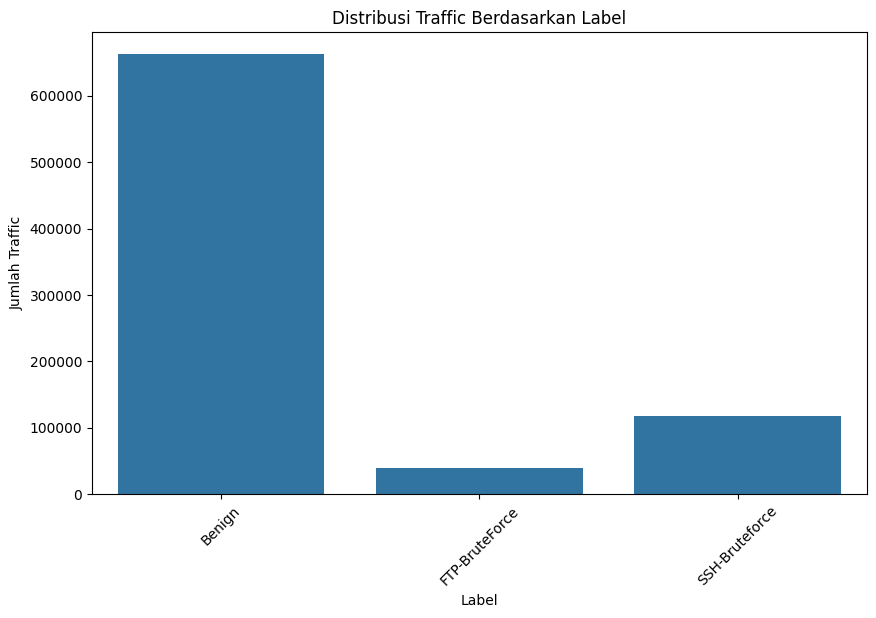

In [13]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="Label")

plt.title("Distribusi Traffic Berdasarkan Label")
plt.xlabel("Label")
plt.ylabel("Jumlah Traffic")
plt.xticks(rotation=45)

plt.show()

d. lihat distribusi fitur numerik

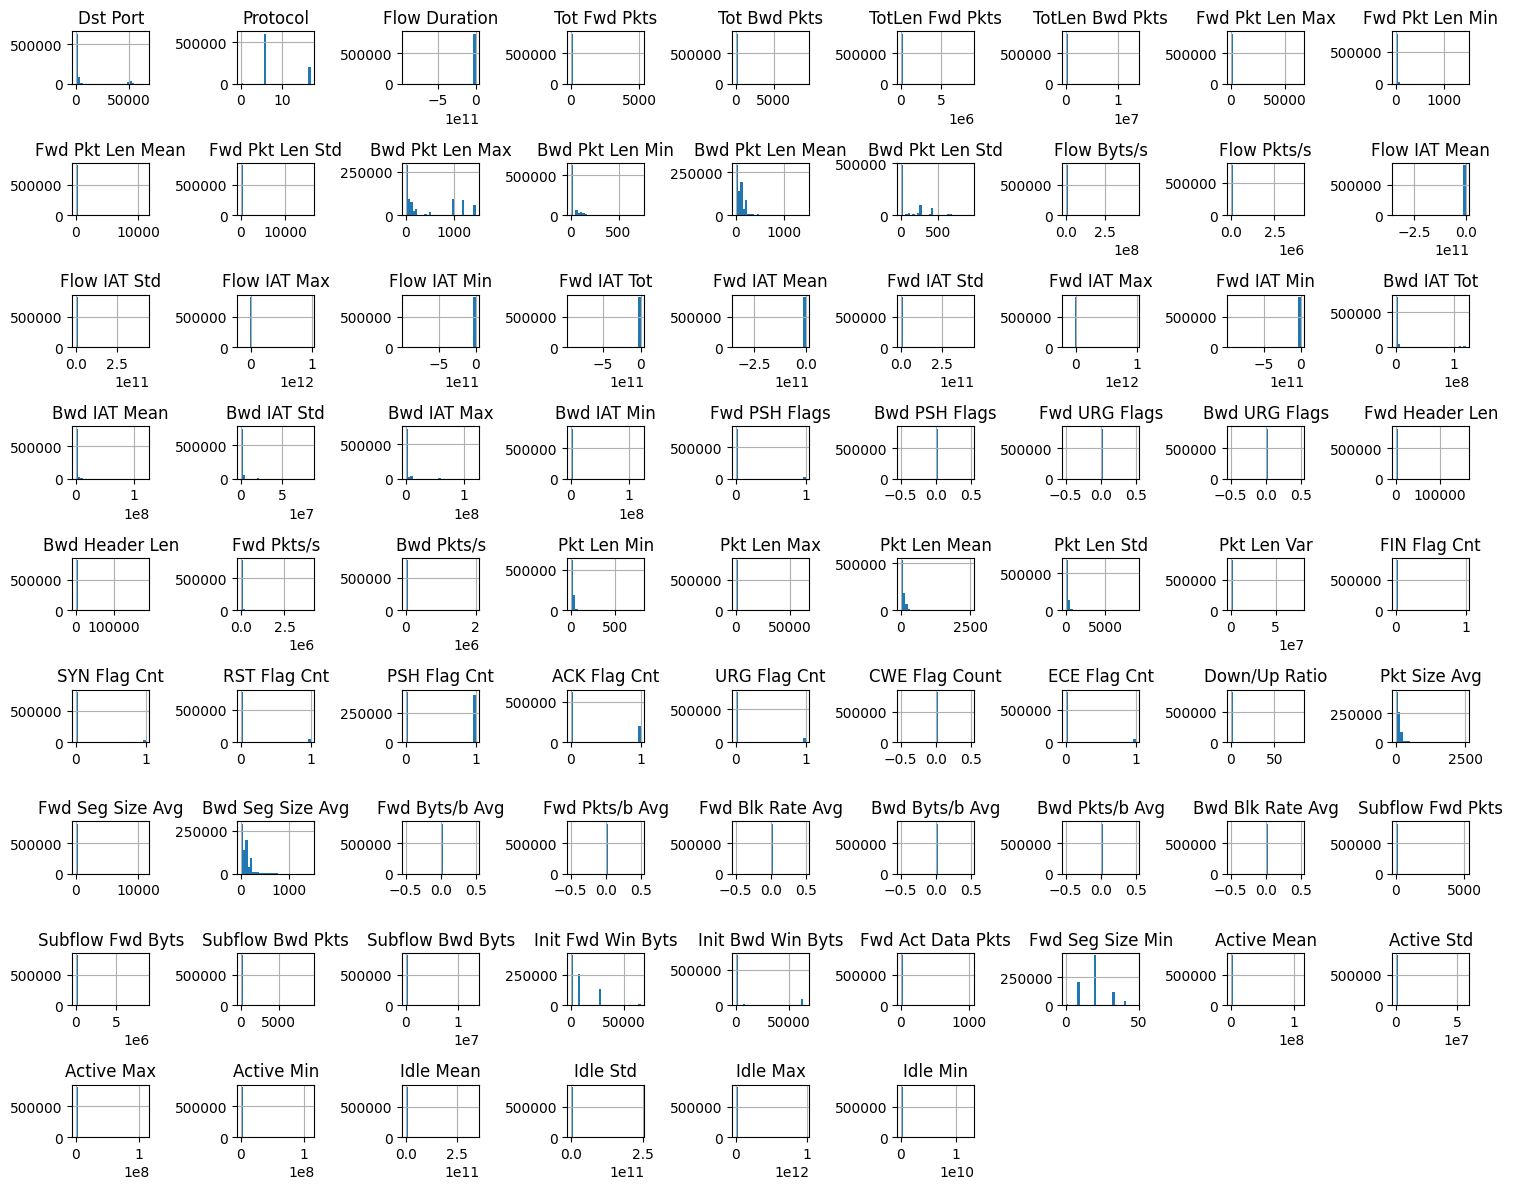

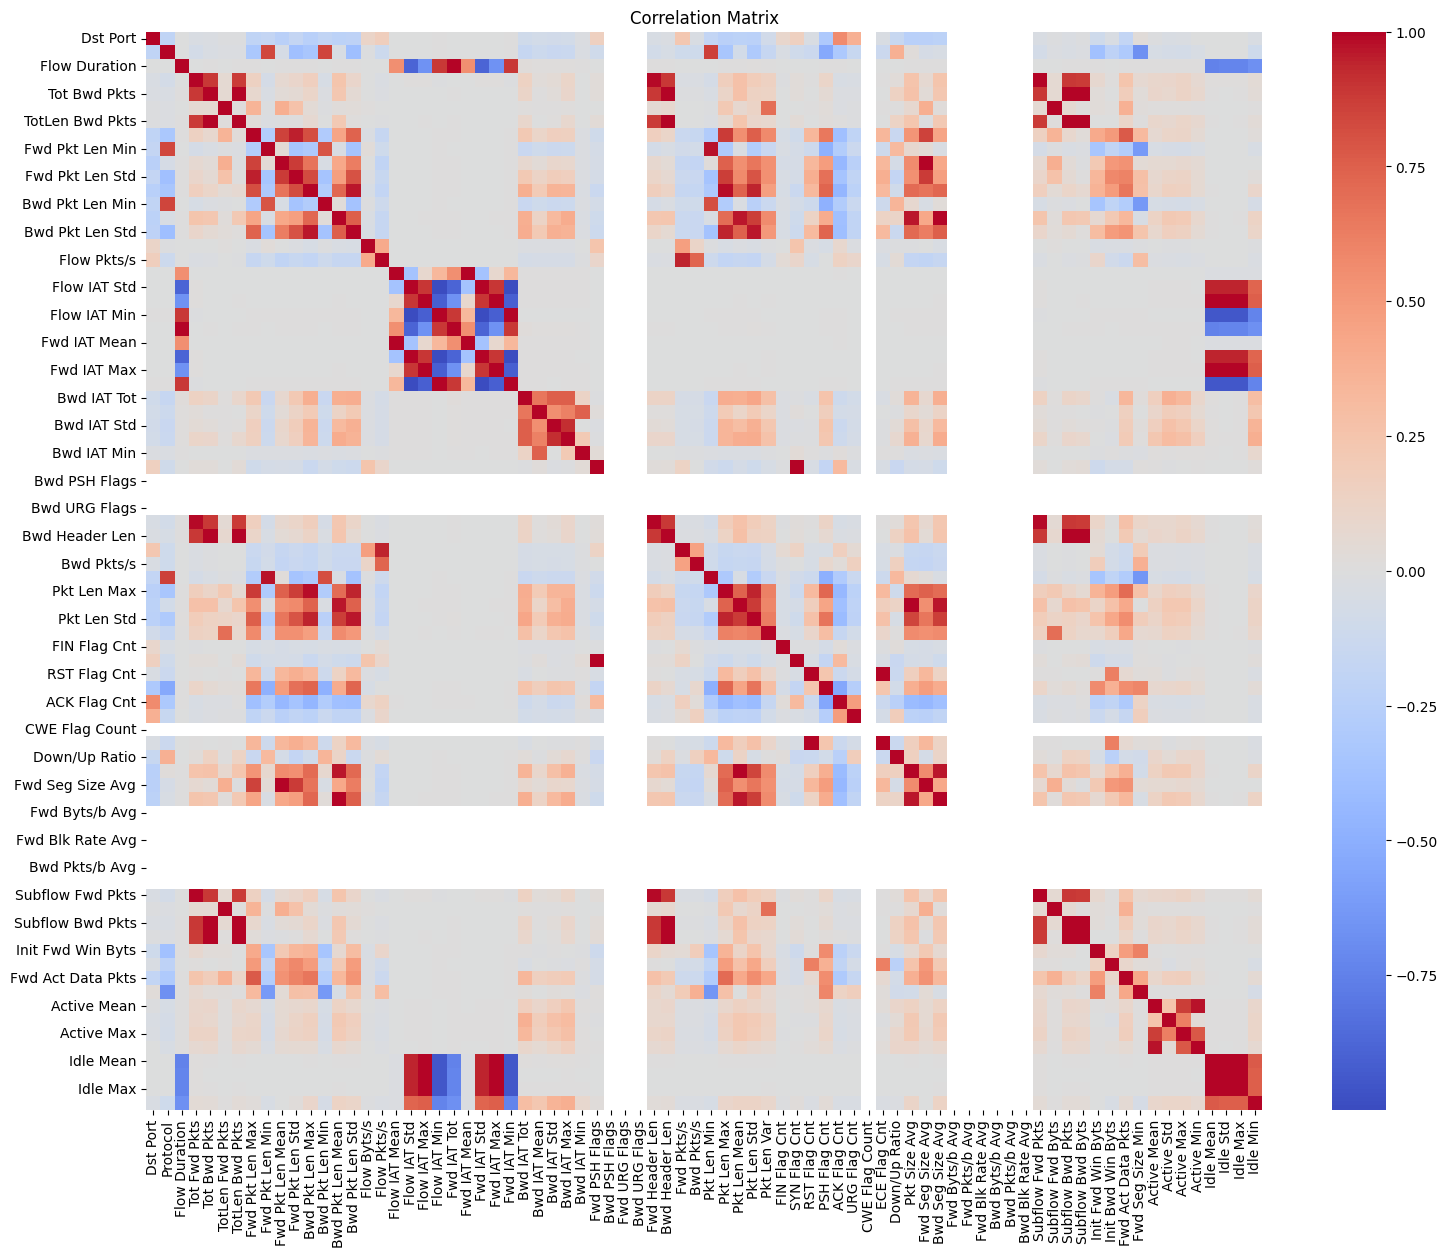

In [14]:
# Digunakan untuk mengetahui karakteristik
# beberapa fitur numerik dalam dataset
df.hist(figsize=(15, 12), bins=30)

plt.tight_layout()
plt.show()


# Melihat korelasi antar fitur numerik
# Digunakan untuk mengetahui hubungan antar fitur
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

# 5. Label, Fitur (x) dan Target (y)

a. lihat label yang tersedia

In [15]:
# Digunakan untuk mengetahui nama label pada dataset
print("Label yang tersedia:")
print(df["Label"].unique())

Label yang tersedia:
['Benign' 'FTP-BruteForce' 'SSH-Bruteforce']


b. menentukan label yang digunakan

In [16]:
# Normal dan Brute Force SSH
# dari df["Label"].unique()
target_labels = [
    "Benign",
    "SSH-Bruteforce"
]


c. ambil data yang memiliki label

In [17]:
# Normal dan Brute Force SSH
df_model = df[df["Label"].isin(target_labels)].copy()

d. cek kembali distribusi label

In [18]:
print("\nDistribusi label setelah filtering:")
print(df_model["Label"].value_counts())



Distribusi label setelah filtering:
Label
Benign            662458
SSH-Bruteforce    117322
Name: count, dtype: int64


e. menentukan nilai y (target)

In [19]:
# Label merupakan target yang ingin diprediksi oleh model
y = df_model["Label"]

f. menentukan nilai x (fitur)

In [20]:
# Timestamp dan Label tidak digunakan sebagai fitur
X = df_model.drop(columns=["Label", "Timestamp", "Dst Port"])

g. melihat jumlah fitur yang digunakan

In [21]:
print("\nJumlah fitur:", X.shape[1])

# Melihat nama fitur
print("\nNama fitur:")
print(X.columns.tolist())


Jumlah fitur: 77

Nama fitur:
['Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', '

# 6. Preprocessing

a. membersihkan nama kolom

In [22]:
# Menghilangkan spasi yang mungkin terdapat pada
# bagian awal atau akhir nama kolom
X.columns = X.columns.str.strip()

b. mengecek tipe data fitur

In [23]:
# Memastikan fitur dapat digunakan oleh model
print("Tipe data fitur:")
print(X.dtypes)

Tipe data fitur:
Protocol             int64
Flow Duration        int64
Tot Fwd Pkts         int64
Tot Bwd Pkts         int64
TotLen Fwd Pkts      int64
                    ...   
Active Min           int64
Idle Mean          float64
Idle Std           float64
Idle Max             int64
Idle Min             int64
Length: 77, dtype: object


c. mengubah label menjadi angka

In [24]:
# Benign dan Brute Force SSH akan diubah menjadi
# nilai numerik agar dapat diproses oleh model
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

d. melihat hasil encoding label

In [25]:
print("\nMapping label:")
for label, encoded in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{label} = {encoded}")


Mapping label:
Benign = 0
SSH-Bruteforce = 1


e. melihat bentuk akhir x (fitur) dan y (target)

In [26]:
print("\nUkuran X:", X.shape)
print("Ukuran y:", y.shape)

print("\nJumlah fitur:", X.shape[1])


Ukuran X: (779780, 77)
Ukuran y: (779780,)

Jumlah fitur: 77


# 7. Split Training Testing

a. membagi dataset menjadi training dan testing

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

b. menanmpilkan ukuran masing-masing data

In [28]:
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (623824, 77)
Ukuran X_test : (155956, 77)
Ukuran y_train: (623824,)
Ukuran y_test : (155956,)


c. mengecek distribusi label pada data training dan testing

In [29]:
# training
print("\nDistribusi label pada data training:")
print(pd.Series(y_train).value_counts())

# testing
print("\nDistribusi label pada data testing:")
print(pd.Series(y_test).value_counts())


Distribusi label pada data training:
0    529966
1     93858
Name: count, dtype: int64

Distribusi label pada data testing:
0    132492
1     23464
Name: count, dtype: int64


# 8. Tangani Imbalanced Data (Data Tidak Seimbang) dengan SMOTE

a. lihat distribusi kelas sebelum SMOTE

In [30]:
print("Distribusi kelas sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

Distribusi kelas sebelum SMOTE:
0    529966
1     93858
Name: count, dtype: int64


b. buat objek SMOTE

In [31]:
# random_state digunakan agar hasil dapat direproduksi
smote = SMOTE(random_state=42)

c. SMOTE pada data training

In [32]:
# X_train dan y_train yang diproses
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

c. lihat distribusi kelas setelah SMOTE

In [33]:
print("\nDistribusi kelas setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts())



Distribusi kelas setelah SMOTE:
0    529966
1    529966
Name: count, dtype: int64


d. lihat ukuran data setelah SMOTE

In [34]:
print("\nUkuran X_train sebelum SMOTE:", X_train.shape)
print("Ukuran X_train setelah SMOTE:", X_train_smote.shape)

print("\nUkuran y_train sebelum SMOTE:", y_train.shape)
print("Ukuran y_train setelah SMOTE:", y_train_smote.shape)


Ukuran X_train sebelum SMOTE: (623824, 77)
Ukuran X_train setelah SMOTE: (1059932, 77)

Ukuran y_train sebelum SMOTE: (623824,)
Ukuran y_train setelah SMOTE: (1059932,)


# 9. Random Forest Model

a. membuat model random forest dan konfigurasinya

In [35]:
model_rf = RandomForestClassifier(
    n_estimators=100,     # Jumlah decision tree
    max_depth=3,          # Kedalaman tree (disamakan dengan LightGBM agar setara)
    random_state=42,      # Agar hasil dapat direproduksi
    n_jobs=-1,            # Pakai semua core CPU biar lebih cepat
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt'
)

In [36]:
# Menampilkan konfigurasi model
print(model_rf)

RandomForestClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=20,
                       n_jobs=-1, random_state=42)


b. training model

In [37]:
# sudah diseimbangkan dengan SMOTE
model_rf.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=20,
                       n_jobs=-1, random_state=42)

# 10. Prediksi

In [38]:
# Membandingkan dengan data testing
y_pred_rf = model_rf.predict(X_test)

print("Hasil prediksi:")
print(y_pred_rf[:20])

print("\nLabel sebenarnya:")
print(y_test[:20])

Hasil prediksi:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]

Label sebenarnya:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]


# 11. Evaluasi Model

In [39]:
# hitung akurasi
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# hitung presisi
precision_rf = precision_score(y_test, y_pred_rf)

# hitung recall
recall_rf = recall_score(y_test, y_pred_rf)

# hitung F1-Score
f1_rf = f1_score(y_test, y_pred_rf)

# tampilkan hasil
print("Hasil Evaluasi Model Random Forest")
print("--------------------------------")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")

Hasil Evaluasi Model Random Forest
--------------------------------
Accuracy  : 0.9952
Precision : 0.9723
Recall    : 0.9966
F1-Score  : 0.9843


In [40]:
# tampilkan classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_
))


Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      0.99      1.00    132492
SSH-Bruteforce       0.97      1.00      0.98     23464

      accuracy                           1.00    155956
     macro avg       0.99      1.00      0.99    155956
  weighted avg       1.00      1.00      1.00    155956



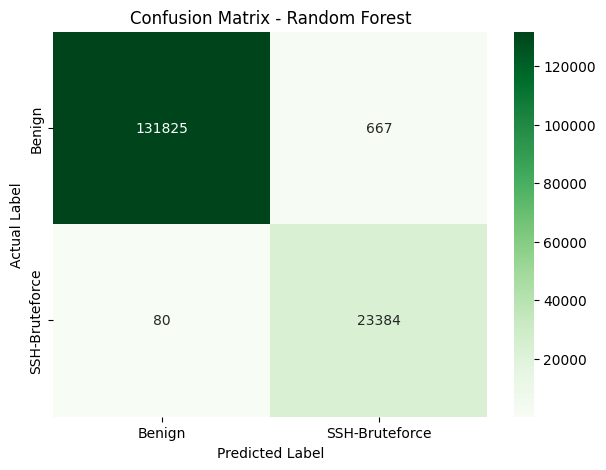

In [41]:
# membuat confusion matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",   # warna dibedakan dari LightGBM (Blues) biar gampang dibedakan pas laporan
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# 12. Feature Importance

In [42]:
# ambil feature importance
importance_rf = model_rf.feature_importances_

# dataframe untuk simpan nama fitur dan importancenya
feature_importance_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance_rf
}).sort_values(by="Importance", ascending=False)

# tampilkan seluruh rangking
print(feature_importance_rf)

# pilih 15 fitur teratas
jumlah_fitur = 15

selected_features_rf = (
    feature_importance_rf
    .head(jumlah_fitur)["Feature"]
    .tolist()
)

             Feature  Importance
68  Fwd Seg Size Min    0.141213
62  Subflow Fwd Byts    0.073075
37        Bwd Pkts/s    0.068126
4    TotLen Fwd Pkts    0.060125
34    Fwd Header Len    0.055737
..               ...         ...
57  Fwd Blk Rate Avg    0.000000
72        Active Min    0.000000
70        Active Std    0.000000
69       Active Mean    0.000000
74          Idle Std    0.000000

[77 rows x 2 columns]


In [43]:
# tampilkan 15 fitur teratas
print("15 fitur terpilih:")
for i, feature in enumerate(selected_features_rf, start=1):
    print(f"{i}. {feature}")

15 fitur terpilih:
1. Fwd Seg Size Min
2. Subflow Fwd Byts
3. Bwd Pkts/s
4. TotLen Fwd Pkts
5. Fwd Header Len
6. Fwd Act Data Pkts
7. Init Fwd Win Byts
8. Tot Fwd Pkts
9. Bwd Header Len
10. Subflow Bwd Pkts
11. Init Bwd Win Byts
12. Subflow Fwd Pkts
13. Fwd Pkts/s
14. Flow Pkts/s
15. Flow Duration


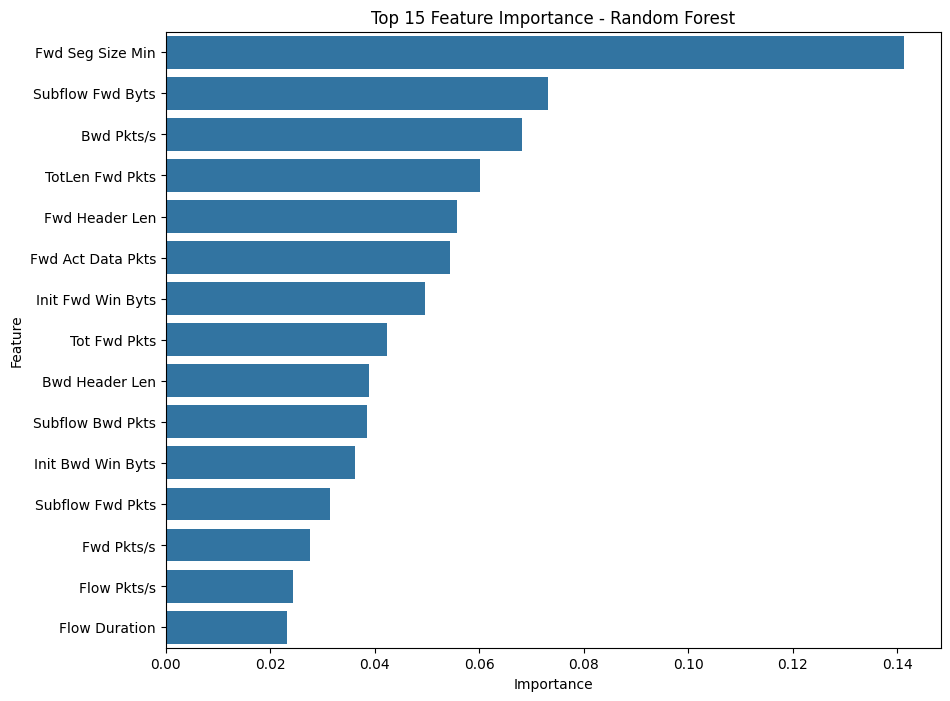

In [44]:
# visualisasi fitur teratas
top_features_rf = feature_importance_rf.head(15)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features_rf,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# 13. Feature Selection

In [45]:
# membentuk X berdasarkan 15 fitur
X_selected_rf = X[selected_features_rf]

In [46]:
# membentuk Y yang sama dengan sebelumnya
y_selected_rf = y

In [47]:
# cek jumlah fitur
print("Jumlah fitur awal :", X.shape[1])
print("Jumlah fitur baru :", X_selected_rf.shape[1])

Jumlah fitur awal : 77
Jumlah fitur baru : 15


In [48]:
# menggunakan split training/testing yang sama dengan baseline
X_train_sel_rf = X_train[selected_features_rf]
X_test_sel_rf = X_test[selected_features_rf]

y_train_sel_rf = y_train
y_test_sel_rf = y_test

In [49]:
print("X_train 15 fitur:", X_train_sel_rf.shape)
print("X_test 15 fitur :", X_test_sel_rf.shape)
print("y_train 15 fitur:", y_train_sel_rf.shape)
print("y_test 15 fitur :", y_test_sel_rf.shape)

print("\nDistribusi y_test 15 fitur:")
print(pd.Series(y_test_sel_rf).value_counts())

X_train 15 fitur: (623824, 15)
X_test 15 fitur : (155956, 15)
y_train 15 fitur: (623824,)
y_test 15 fitur : (155956,)

Distribusi y_test 15 fitur:
0    132492
1     23464
Name: count, dtype: int64


# 14. SMOTE pada 15 fitur terpilih

In [50]:
# buat objek SMOTE baru
smote_selected_rf = SMOTE(random_state=42)

In [51]:
# SMOTE pada data training
X_train_sel_rf_smote, y_train_sel_rf_smote = (
    smote_selected_rf.fit_resample(
        X_train_sel_rf,
        y_train_sel_rf
    )
)

In [52]:
# Cek distribusi SMOTE
print("Distribusi sebelum SMOTE:")
print(pd.Series(y_train_sel_rf).value_counts())
print("\nDistribusi setelah SMOTE:")
print(pd.Series(y_train_sel_rf_smote).value_counts())

Distribusi sebelum SMOTE:
0    529966
1     93858
Name: count, dtype: int64

Distribusi setelah SMOTE:
0    529966
1    529966
Name: count, dtype: int64


In [53]:
# cek ukuran
print("\nX_train sebelum :", X_train_sel_rf.shape)
print("X_train sesudah :", X_train_sel_rf_smote.shape)


X_train sebelum : (623824, 15)
X_train sesudah : (1059932, 15)


# 15. Training Ulang Random Forest 15 fitur

In [54]:
# buat model baru berdasarkan 15 fitur terpilih
model_rf_selected = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

In [55]:
# training dengan SMOTE 15 fitur
model_rf_selected.fit(
    X_train_sel_rf_smote,
    y_train_sel_rf_smote
)

RandomForestClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=20,
                       n_jobs=-1, random_state=42)

In [56]:
# Evaluasi model RF 15 fitur

# prediction
y_pred_sel_rf = model_rf_selected.predict(X_test_sel_rf)

# accuracy
accuracy_sel_rf = accuracy_score(
    y_test_sel_rf,
    y_pred_sel_rf
)

# precision
precision_sel_rf = precision_score(
    y_test_sel_rf,
    y_pred_sel_rf
)

# recall
recall_sel_rf = recall_score(
    y_test_sel_rf,
    y_pred_sel_rf
)

# F1-score
f1_sel_rf = f1_score(
    y_test_sel_rf,
    y_pred_sel_rf
)



In [57]:
# Tampilkan evaluasi 15 fitur
print("Hasil Evaluasi Random Forest - 15 Fitur")
print("----------------------------------------")
print(f"Accuracy  : {accuracy_sel_rf:.4f}")
print(f"Precision : {precision_sel_rf:.4f}")
print(f"Recall    : {recall_sel_rf:.4f}")
print(f"F1-Score  : {f1_sel_rf:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_sel_rf,
        y_pred_sel_rf,
        target_names=label_encoder.classes_
    )
)

Hasil Evaluasi Random Forest - 15 Fitur
----------------------------------------
Accuracy  : 0.9996
Precision : 0.9999
Recall    : 0.9973
F1-Score  : 0.9986

Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    132492
SSH-Bruteforce       1.00      1.00      1.00     23464

      accuracy                           1.00    155956
     macro avg       1.00      1.00      1.00    155956
  weighted avg       1.00      1.00      1.00    155956



In [58]:
# Confusion matrix 15 fitur

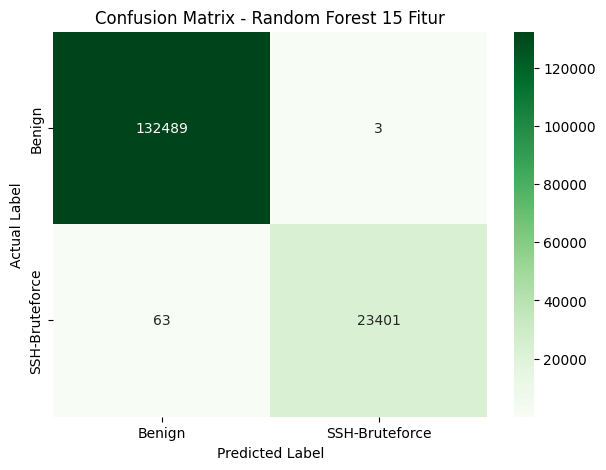

In [59]:
cm_sel_rf = confusion_matrix(
    y_test_sel_rf,
    y_pred_sel_rf
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_sel_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Random Forest 15 Fitur")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# 16. Feature selection 14 fitur

In [60]:
selected_features_14 = selected_features_rf[:14]

print("14 fitur yang digunakan:")
for i, feature in enumerate(selected_features_14, start=1):
    print(f"{i}. {feature}")


14 fitur yang digunakan:
1. Fwd Seg Size Min
2. Subflow Fwd Byts
3. Bwd Pkts/s
4. TotLen Fwd Pkts
5. Fwd Header Len
6. Fwd Act Data Pkts
7. Init Fwd Win Byts
8. Tot Fwd Pkts
9. Bwd Header Len
10. Subflow Bwd Pkts
11. Init Bwd Win Byts
12. Subflow Fwd Pkts
13. Fwd Pkts/s
14. Flow Pkts/s


In [61]:
# Gunakan split yang SAMA dengan baseline
X_train_14 = X_train[selected_features_14]
X_test_14 = X_test[selected_features_14]

y_train_14 = y_train
y_test_14 = y_test

print("\nUkuran data:")
print("X_train sebelum SMOTE :", X_train_14.shape)
print("X_test               :", X_test_14.shape)


Ukuran data:
X_train sebelum SMOTE : (623824, 14)
X_test               : (155956, 14)


# 17. SMOTE 14 fitur

In [62]:
# SMOTE hanya pada training
smote_14 = SMOTE(random_state=42)

X_train_14_smote, y_train_14_smote = smote_14.fit_resample(
    X_train_14,
    y_train_14
)

print("X_train setelah SMOTE :", X_train_14_smote.shape)

X_train setelah SMOTE : (1059932, 14)


# 18. Training Ulang RF 14 fitur

In [63]:
# Random Forest dengan parameter yang sama
model_rf_14 = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

In [64]:
# Training
model_rf_14.fit(
    X_train_14_smote,
    y_train_14_smote
)

RandomForestClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=20,
                       n_jobs=-1, random_state=42)

In [65]:
# Prediksi
y_pred_14 = model_rf_14.predict(X_test_14)

In [66]:
# Evaluasi
accuracy_14 = accuracy_score(y_test_14, y_pred_14)
precision_14 = precision_score(y_test_14, y_pred_14)
recall_14 = recall_score(y_test_14, y_pred_14)
f1_14 = f1_score(y_test_14, y_pred_14)

print("\nHasil Evaluasi Random Forest - 14 Fitur")
print("----------------------------------------")
print(f"Accuracy  : {accuracy_14:.4f}")
print(f"Precision : {precision_14:.4f}")
print(f"Recall    : {recall_14:.4f}")
print(f"F1-Score  : {f1_14:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_14,
        y_pred_14,
        target_names=label_encoder.classes_
    )
)


Hasil Evaluasi Random Forest - 14 Fitur
----------------------------------------
Accuracy  : 0.9999
Precision : 0.9998
Recall    : 0.9997
F1-Score  : 0.9998

Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    132492
SSH-Bruteforce       1.00      1.00      1.00     23464

      accuracy                           1.00    155956
     macro avg       1.00      1.00      1.00    155956
  weighted avg       1.00      1.00      1.00    155956



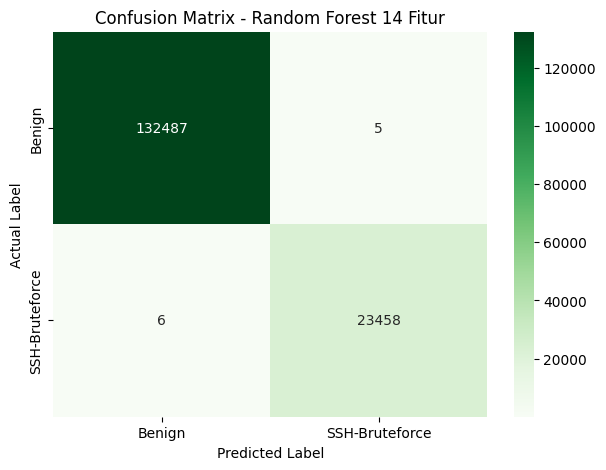

In [67]:
# Confusion Matrix
cm_14 = confusion_matrix(
    y_test_14,
    y_pred_14
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_14,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Random Forest 14 Fitur")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# 19. Tuning RF menggunakan Optuna

In [68]:
!pip install optuna

In [69]:
import optuna

from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [70]:
# Gunakan 14 fitur
print("X_train_14 :", X_train_14.shape)
print("X_test_14  :", X_test_14.shape)
print("y_train_14 :", y_train_14.shape)
print("y_test_14  :", y_test_14.shape)

X_train_14 : (623824, 14)
X_test_14  : (155956, 14)
y_train_14 : (623824,)
y_test_14  : (155956,)


In [71]:
# cross validation
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [72]:
# objektif optuna
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 300, step=50
        ),

        "max_depth": trial.suggest_categorical(
            "max_depth",
            [3, 5, 8, 12, 16, None]
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split", 2, 20, step=2
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 1, 10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", 0.5]
        )
    }

    pipeline = Pipeline([
        (
            "smote",
            SMOTE(random_state=42)
        ),
        (
            "rf",
            RandomForestClassifier(
                **params,
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    scores = cross_val_score(
        pipeline,
        X_train_14,
        y_train_14,
        cv=cv,
        scoring="f1",
        n_jobs=1
    )

    return scores.mean()

In [73]:
# studi optuna
study = optuna.create_study(
    direction="maximize",
    study_name='RF_14_Fitur',
    sampler=optuna.samplers.TPESampler(
        seed=42
    )
)

[I 2026-09-23 03:28:34,461] A new study created in memory with name: RF_14_Fitur


In [74]:
study.optimize(
    objective,
    n_trials=10,
    show_progress_bar=True
)

  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-09-23 03:34:09,892] Trial 0 finished with value: 0.9994781704723087 and parameters: {'n_estimators': 150, 'max_depth': 3, 'min_samples_split': 18, 'min_samples_leaf': 7, 'max_features': 0.5}. Best is trial 0 with value: 0.9994781704723087.
[I 2026-09-23 03:47:26,925] Trial 1 finished with value: 0.9999147604301596 and parameters: {'n_estimators': 300, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 0.5}. Best is trial 1 with value: 0.9999147604301596.
[I 2026-09-23 03:51:29,293] Trial 2 finished with value: 0.9996271769430803 and parameters: {'n_estimators': 200, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 1 with value: 0.9999147604301596.
[I 2026-09-23 03:55:21,292] Trial 3 finished with value: 0.9998934496009854 and parameters: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9999147604301596.
[I 

In [75]:
print("Best F1 CV:")
print(f"{study.best_value:.4f}")

print("\nBest Parameters:")
print(study.best_params)

Best F1 CV:
0.9999

Best Parameters:
{'n_estimators': 300, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 0.5}


# 20. Training Random Forest Dengan Parameter Terbaik

In [76]:
best_params = study.best_params
model_rf_14_tuned = Pipeline([
    (
        "smote",
        SMOTE(random_state=42)
    ),
    (
        "rf",
        RandomForestClassifier(
            **best_params,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [77]:
model_rf_14_tuned.fit(
    X_train_14,
    y_train_14
)

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('rf',
                 RandomForestClassifier(max_depth=16, max_features=0.5,
                                        min_samples_leaf=7, min_samples_split=6,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [78]:
# evaluasi pada test set
y_pred_14_tuned = model_rf_14_tuned.predict(
    X_test_14
)
accuracy_14_tuned = accuracy_score(
    y_test_14,
    y_pred_14_tuned
)

precision_14_tuned = precision_score(
    y_test_14,
    y_pred_14_tuned
)

recall_14_tuned = recall_score(
    y_test_14,
    y_pred_14_tuned
)

f1_14_tuned = f1_score(
    y_test_14,
    y_pred_14_tuned
)

In [79]:
# tampilkan hasil
print("Hasil Evaluasi Random Forest 14 Fitur - Optuna")
print("------------------------------------------------")
print(f"Accuracy  : {accuracy_14_tuned:.4f}")
print(f"Precision : {precision_14_tuned:.4f}")
print(f"Recall    : {recall_14_tuned:.4f}")
print(f"F1-Score : {f1_14_tuned:.4f}")

Hasil Evaluasi Random Forest 14 Fitur - Optuna
------------------------------------------------
Accuracy  : 1.0000
Precision : 0.9999
Recall    : 1.0000
F1-Score : 1.0000


In [80]:
print("\nClassification Report:")

print(
    classification_report(
        y_test_14,
        y_pred_14_tuned,
        target_names=label_encoder.classes_
    )
)


Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    132492
SSH-Bruteforce       1.00      1.00      1.00     23464

      accuracy                           1.00    155956
     macro avg       1.00      1.00      1.00    155956
  weighted avg       1.00      1.00      1.00    155956



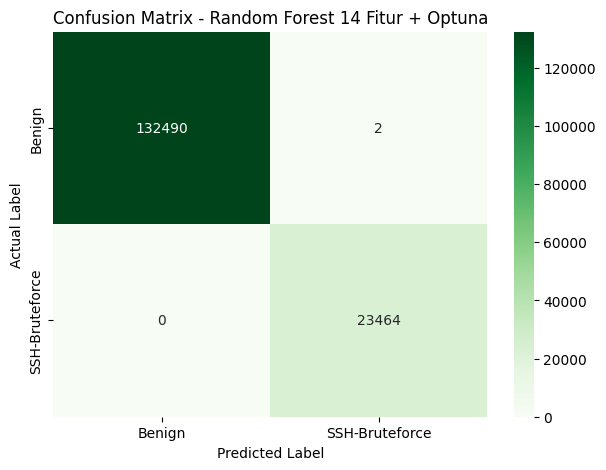

In [81]:
# confusion matrix
cm_14_tuned = confusion_matrix(
    y_test_14,
    y_pred_14_tuned
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_14_tuned,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    "Confusion Matrix - Random Forest 14 Fitur + Optuna"
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [82]:
# bandingkan hasil dengan sebelum tuning
hasil_tuning = pd.DataFrame({
    "Model": [
        "RF 14 Fitur",
        "RF 14 Fitur + Optuna"
    ],

    "Accuracy": [
        accuracy_14,
        accuracy_14_tuned
    ],

    "Precision": [
        precision_14,
        precision_14_tuned
    ],

    "Recall": [
        recall_14,
        recall_14_tuned
    ],

    "F1-Score": [
        f1_14,
        f1_14_tuned
    ]
})

display(
    hasil_tuning.style.format({
        "Accuracy": "{:.4%}",
        "Precision": "{:.4%}",
        "Recall": "{:.4%}",
        "F1-Score": "{:.4%}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score
0,RF 14 Fitur,99.9929%,99.9787%,99.9744%,99.9766%
1,RF 14 Fitur + Optuna,99.9987%,99.9915%,100.0000%,99.9957%
